In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [5]:
import pandas as pd

dataset = pd.read_csv("/content/spam.csv", encoding="latin-1")

print(dataset.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [6]:
dataset = dataset.rename(columns={
    'v1': 'Category',
    'v2': 'Message'
})

print(dataset.head())

  Category                                            Message Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [7]:
dataset = dataset[['Category', 'Message']]

print(dataset.head())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
X = dataset['Message'].values
y = dataset['Category'].values

print("X:", X[:5])
print("y:", y[:5])

X: ['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
 'U dun say so early hor... U c already then say...'
 "Nah I don't think he goes to usf, he lives around here though"]
y: ['ham' 'ham' 'spam' 'ham' 'ham']


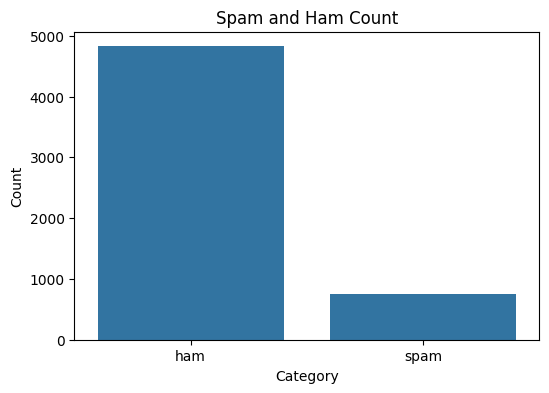

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='Category', data=dataset)

plt.title("Spam and Ham Count")
plt.xlabel("Category")
plt.ylabel("Count")

plt.savefig("exercise3a.png")

plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 4457
Testing data: 1115


In [12]:
cv = CountVectorizer()

X_train = cv.fit_transform(X_train)

X_test = cv.transform(X_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (4457, 7612)
Testing shape: (1115, 7612)


In [13]:
classifier = SVC(
    kernel='rbf',
    random_state=0
)

classifier.fit(X_train, y_train)

print("SVM training completed!")

SVM training completed!


In [14]:
print(classifier.score(X_test, y_test))

0.9766816143497757


In [15]:
accuracy = classifier.score(X_test, y_test)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9766816143497757
Accuracy Percentage: 97.66816143497758 %
